# 포인트 미션 상관관계 분석 — 부채 관점 (한글 플롯판)

**기준일 2026-08-04 · 30일 윈도우 2026-07-06 ~ 2026-08-04**

포인트는 발행 시점에 회사의 **부채**로 잡힙니다. 이 노트북은 그 전제에서 세 가지를 봅니다.

1. **무분별하게 나가는 포인트가 있는가** — 발행 집중도, 소수 사용자 편중, 관리자 재량 지급
2. **없어도 되는 미션은 무엇인가** — 도달률이 0이거나, 다른 미션과 완전히 겹쳐서 빼도 잃는 사용자가 없는 미션
3. **의미가 있어 유지할 미션은 무엇인가** — 참여가 실제 앱 활동과 연결되는 미션

데이터는 `data/csv/` 의 CSV 를 읽습니다. 재생성은 `bash data/sql/build_all.sh`.

> **해석상 주의.** 이 데이터는 단면(cross-section)입니다. "미션 참여자가 활동적이다"는 것과
> "미션이 활동을 만들었다"는 것은 다릅니다. 원래 활발한 사용자가 미션도 많이 수행한다는 역인과가
> 항상 가능하므로, 아래에서는 전체 활동량을 통제한 **조정 연관(adjusted association)** 까지만 주장합니다.

> 이 노트북은 `point_mission_liability.ipynb` 와 내용이 같고, **플롯의 글자만 한글**입니다.
> 플롯 폰트는 D2Coding(고정폭)을 씁니다. 폰트가 없으면 첫 셀에서 실패하므로 그때는 영문판을 쓰시면 됩니다.

In [1]:
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.font_manager import FontProperties, fontManager
from scipy import stats

warnings.filterwarnings("ignore")

# ── 폰트 ────────────────────────────────────────────────────────────────────
# 플롯 안의 글자는 전부 영문으로 씁니다 (PDF 변환 시 한글 깨짐 방지).
# D2Coding 이 설치돼 있으면 fallback 으로 등록해 두어, 혹시 한글이 섞여도 렌더는 되게 합니다.
_d2 = [p for p in (Path.home() / "Library/Fonts").glob("D2Coding*.ttf")]
for _p in _d2:
    fontManager.addfont(str(_p))
if not _d2:
    raise RuntimeError("D2Coding 폰트를 찾지 못했습니다. ~/Library/Fonts 에 설치하세요. "
                       "영문 플롯 버전은 point_mission_liability.ipynb 를 쓰면 됩니다.")
# D2Coding 을 1순위로. 한글 글리프가 있어 축·범례·제목 모두 한글로 렌더됩니다.
# 없는 글리프(일부 기호)는 DejaVu Sans 로 폴백합니다.
mpl.rcParams["font.family"] = ["D2Coding", "DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.autolayout": True,
})
print("D2Coding 등록:", bool(_d2))

# 노트북을 repo 루트에서 열든 analysis/ 에서 열든 같은 곳을 가리키도록 위로 거슬러 찾는다.
def _find_data() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "csv" / "01_mission_catalog.csv").exists():
            return base / "data" / "csv"
    raise FileNotFoundError("data/csv 를 찾지 못했습니다. 먼저 `bash data/sql/build_all.sh` 를 실행하세요.")

DATA = _find_data()
REF_DATE, WINDOW_DAYS = "2026-08-04", 30

catalog   = pd.read_csv(DATA / "01_mission_catalog.csv")
users     = pd.read_csv(DATA / "02_user_activity_30d.csv")
earn      = pd.read_csv(DATA / "03_mission_user_earn_30d.csv")
mua       = pd.read_csv(DATA / "04_mission_user_activity_30d.csv")
liability = pd.read_csv(DATA / "06_point_liability_by_mission.csv")
monthly   = pd.read_csv(DATA / "07_mission_monthly_issue.csv", parse_dates=["month"])
audit     = pd.read_csv(DATA / "08_admin_grant_audit.csv")

# PostgreSQL COPY 는 boolean 을 't'/'f' 로 씁니다 — pandas 가 문자열로 읽으므로 되돌린다.
for _c in ["is_recipient", "meets_12w_rule", "answered_every_eligible_week",
           "under_12w_at_payout", "meets_own12_rule"]:
    audit[_c] = audit[_c].map({"t": True, "f": False})

print({k: v.shape for k, v in
       dict(catalog=catalog, users=users, earn=earn, mua=mua,
            liability=liability, monthly=monthly, audit=audit).items()})

D2Coding 등록: True
{'catalog': (43, 34), 'users': (482, 65), 'earn': (2251, 11), 'mua': (2251, 68), 'liability': (34, 20), 'monthly': (238, 6), 'audit': (442, 23)}


In [2]:
# ── 미션 한글 라벨 ──────────────────────────────────────────────────────────
# 플롯 축·범례에 쓸 짧은 한글 이름. 원문 설명은 표에서 그대로 씁니다.
LABEL = {
    1: "회원가입", 2: "성향문진", 3: "글쓰기(30자+)", 5: "좋아요 10개",
    6: "연속 글쓰기 3일", 7: "연속 글쓰기 5일", 8: "연속 글쓰기 7일", 9: "AI 글쓰기",
    43: "댓글 쓰기",
    10: "애드센스 연동", 11: "게임 실행", 12: "게임 랭킹 1위", 13: "게임 랭킹 2~10위",
    14: "출석 1·2·4·5일차", 15: "출석 3·6일차", 16: "출석 7일차",
    17: "글 공유 유입", 18: "유형카드 공유 유입",
    19: "첫 친구 초대", 20: "친구 초대 2~19명", 21: "친구 초대 5명", 22: "친구 초대 10·20명",
    23: "친구 초대 15명", 24: "친구 초대 21~50명", 25: "친구 초대 51~100명",
    26: "친구 초대 101~1000명",
    34: "생활문진 업데이트", 35: "첫 7일 연속 루틴(삭제됨)",
    36: "7일 연속 루틴 수행", 37: "루틴 1개 응답", 38: "식단 등록",
    39: "일일 피드백", 40: "가족 등록 수락",
    41: "12주 완주", 42: "만족도 조사",
    101: "관리자 수동 지급",
    102: "지타이 개인화 시작", 103: "지타이 기준선 생성",
    104: "기분 기록 1~6일", 105: "기분 기록 7일", 106: "기분 기록 8~13일",
    107: "기분 기록 14일", 108: "기분 기록 15일+", 109: "주간 체크업",
}

def label(no) -> str:
    if pd.isna(no):
        return "(미분류)"
    return LABEL.get(int(no), f"미션 #{int(no)}")

# 미션이 세는 행동 = 우리가 활동 지표로 쓰는 행동인 경우.
# 이런 미션은 활동과의 상관이 높게 나오는 것이 당연하므로(동어반복) 따로 표시합니다.
TAUTOLOGICAL = {
    3: "post_publish_cnt_30d", 5: "post_like_cnt_30d", 6: "post_publish_cnt_30d",
    7: "post_publish_cnt_30d", 8: "post_publish_cnt_30d", 43: "comment_cnt_30d",
    14: "attendance_days_30d", 15: "attendance_days_30d", 16: "attendance_days_30d",
    17: "share_cnt_30d", 18: "share_cnt_30d",
    34: "survey_cnt_30d", 35: "routine_done_30d", 36: "routine_done_30d",
    37: "routine_done_30d", 39: "routine_fdbk_cnt_30d",
    104: "jitai_action_cnt_30d", 105: "jitai_action_cnt_30d", 106: "jitai_action_cnt_30d",
    107: "jitai_action_cnt_30d", 108: "jitai_action_cnt_30d",
}

liability["label"] = liability.point_mission_no.map(label)
catalog["label"]   = catalog.point_mission_no.map(label)
monthly["label"]   = monthly.point_mission_no.map(label)
earn["label"]      = earn.point_mission_no.map(label)

# 색상 — 부채 관점의 의미를 담아 고정
C = {"issued": "#3b6fb6", "outstanding": "#c1443c", "used": "#7a9a4a",
     "muted": "#9aa0a6", "accent": "#d98d2b", "dark": "#2f3437"}

# 표에 찍히는 컬럼명을 한글로 바꾸는 매핑입니다.
COLS: dict[str, str] = {
    # 미션 속성
    "point_mission_no": "미션번호", "label": "미션", "mission_description": "미션 설명",
    "description": "설명", "mission_type": "유형", "category_name": "카테고리",
    "parent_category_name": "상위 카테고리", "mission_use_yn": "사용", "use_yn": "사용",
    "mission_del_yn": "삭제", "amount": "지급액", "limit_type": "제한유형",
    # 포인트 금액
    "points_issued": "누적 발행", "points_issued_30d": "30일 발행",
    "points_issued_per_user": "1인당 발행", "points_outstanding": "미상환 잔액",
    "points_used": "사용", "points_returned": "반환", "누적비중": "누적 비중",
    "points": "포인트", "points_per_earner": "적립자당 포인트",
    "points_granted": "지급액", "총_지급액": "총 지급액",
    # 사람 수
    "users": "인원", "users_all_time": "누적 인원", "earners": "적립자",
    "total_unique_users": "누적 적립자", "n_joined": "적립자",
    "n_not": "미적립자", "exclusive_earners": "전속 적립자",
    "exclusive_rate": "전속 비율", "points_per_exclusive": "전속 1인당 포인트",
    # 집중도
    "gini": "지니계수", "top10_share": "상위10% 몫", "max_user_share": "최다 1인 몫",
    # 효과 추정
    "mean_joined": "적립자 평균", "mean_not": "미적립자 평균",
    "raw_diff": "단순 차이", "p_raw": "p(단순)",
    "adj_coef": "조정 계수", "p_adj": "p(조정)",
    "tautology": "동어반복", "cost_per_effect": "효과 1%p당 비용",
    # 감사
    "batch": "배치", "avg_weeks_answered": "평균 응답 주",
    "avg_weeks": "평균 응답 주", "n_zero_weeks": "응답 0주",
    "n_meets_rule": "12주 전부 응답", "충족": "충족 인원",
    "grant_rows": "지급 건수", "weeks_answered_12w": "응답한 주",
    "weeks_assigned_12w": "배정된 주", "own12_weeks_answered": "자기창 응답 주",
    # 기타
    "last_earn_at": "마지막 적립", "first_earn_at": "최초 적립",
}

def show(df, fmt: dict | None = None, index: bool = False):
    """컬럼명을 COLS 로 바꿔 표를 출력합니다. fmt 의 키도 같이 옮겨줍니다."""
    d = df.rename(columns=COLS)
    styler = d.style.format({COLS.get(k, k): v for k, v in (fmt or {}).items()})
    display(styler if index else styler.hide(axis="index"))

print(f"라벨링된 미션: {len(LABEL)}개")

라벨링된 미션: 44개


---
## 1. 포인트 부채 현황

발행된 포인트 중 아직 쓰이지 않은 잔액이 곧 미상환 부채입니다.
`tb_point_user_dtl` 은 적립 1건 = 1행(lot)이고 사용·반환은 같은 행을 갱신하므로,
`sum(get_point) − sum(use_point) − sum(rtn_point) = sum(get_point_balance)` 로 검산됩니다.

In [3]:
issued      = liability.points_issued.sum()
outstanding = liability.points_outstanding.sum()
used        = liability.points_used.sum()
returned    = liability.points_returned.sum()
issued_30d  = liability.points_issued_30d.sum()

assert issued - used - returned == outstanding, "ledger does not reconcile"

summary = pd.DataFrame({
    "항목": ["누적 발행", "누적 사용(상환)", "반환", "미상환 잔액 (= 부채)", "최근 30일 발행"],
    "포인트": [issued, used, returned, outstanding, issued_30d],
})
summary["발행 대비"] = (summary.포인트 / issued).map("{:.1%}".format)
show(summary, {"포인트": "{:,.0f}"})

burn = issued_30d / WINDOW_DAYS
print(f"30일 평균 발행 속도 : {burn:,.0f} P/day  (연 환산 {burn*365:,.0f} P)")
print(f"상환율(사용/발행)   : {used/issued:.1%}   —  나머지 {outstanding/issued:.1%} 가 잔여 부채")

항목,포인트,발행 대비
누적 발행,"8,224,195",100.0%
누적 사용(상환),"3,919,100",47.7%
반환,"91,017",1.1%
미상환 잔액 (= 부채),"4,214,078",51.2%
최근 30일 발행,"2,120,382",25.8%


30일 평균 발행 속도 : 70,679 P/day  (연 환산 25,797,981 P)
상환율(사용/발행)   : 47.7%   —  나머지 51.2% 가 잔여 부채


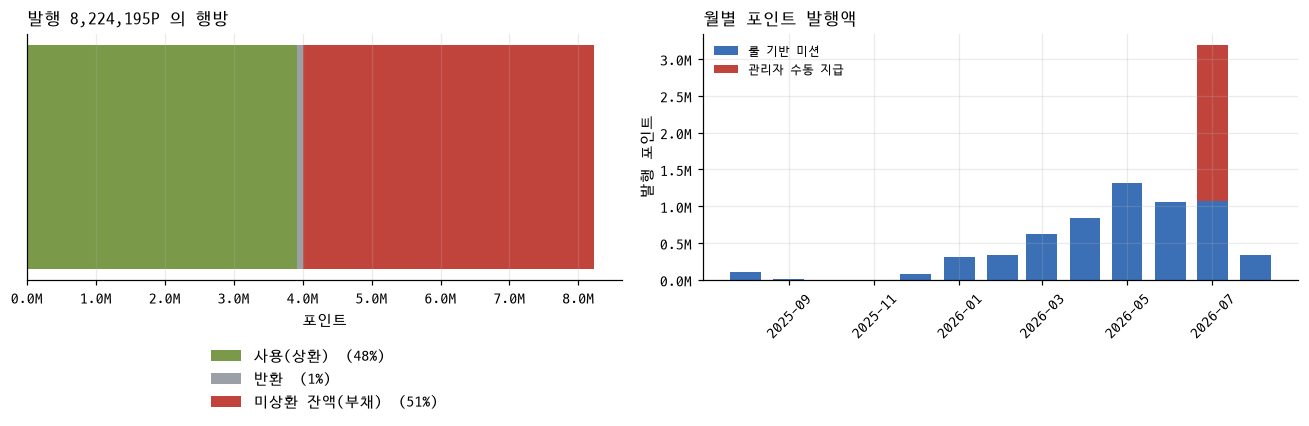

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) 발행액의 행방
ax = axes[0]
parts = [("사용(상환)", used, C["used"]), ("반환", returned, C["muted"]),
         ("미상환 잔액(부채)", outstanding, C["outstanding"])]
left = 0
for name, val, col in parts:
    ax.barh([0], [val], left=left, color=col, label=f"{name}  ({val/issued:.0%})", height=0.5)
    left += val
ax.set_yticks([])
ax.set_xlabel("포인트")
ax.set_title(f"발행 {issued:,.0f}P 의 행방", loc="left", fontsize=11)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=1, frameon=False)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))

# (b) 월별 발행 추이 — 재량 지급과 룰 기반 미션을 분리해서 쌓는다
ax = axes[1]
monthly["is_admin"] = monthly.point_mission_no == 101
mth = (monthly.pivot_table(index="month", columns="is_admin",
                           values="points_issued", aggfunc="sum")
       .reindex(columns=[False, True]).fillna(0))
ax.bar(mth.index, mth[False], width=22, color=C["issued"], label="룰 기반 미션")
ax.bar(mth.index, mth[True], width=22, bottom=mth[False],
       color=C["outstanding"], label="관리자 수동 지급")
ax.set_title("월별 포인트 발행액", loc="left", fontsize=11)
ax.set_ylabel("발행 포인트")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.show()

### 1.1 어떤 미션이 부채를 만드는가

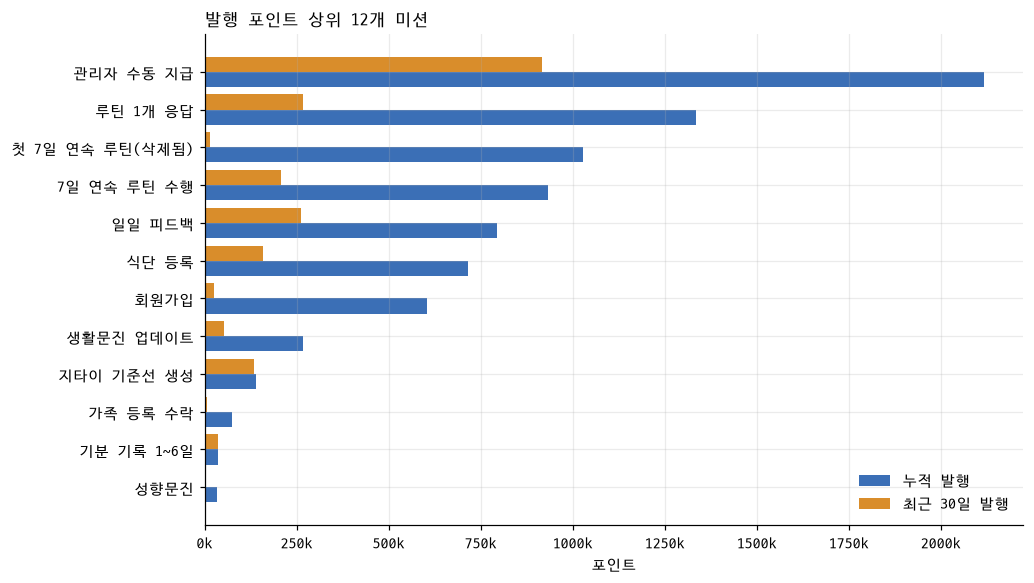

발행 포인트의 80% 를 상위 6개 미션이 차지합니다 (전체 34개 중).


In [5]:
top = liability.sort_values("points_issued", ascending=False).head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(9.5, 5.4))
y = np.arange(len(top))
ax.barh(y - 0.2, top.points_issued, height=0.4, color=C["issued"], label="누적 발행")
ax.barh(y + 0.2, top.points_issued_30d, height=0.4, color=C["accent"], label="최근 30일 발행")
ax.set_yticks(y, top.label)
ax.set_xlabel("포인트")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
ax.set_title("발행 포인트 상위 12개 미션", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower right")
plt.show()

share = liability.sort_values("points_issued", ascending=False).copy()
share["누적비중"] = share.points_issued.cumsum() / issued
n80 = int((share.누적비중 < 0.8).sum() + 1)
print(f"발행 포인트의 80% 를 상위 {n80}개 미션이 차지합니다 (전체 {len(share)}개 중).")

In [6]:
view = (liability.sort_values("points_issued", ascending=False)
        .assign(누적비중=lambda d: (d.points_issued.cumsum() / issued))
        .loc[:, ["point_mission_no", "label", "mission_description", "mission_use_yn",
                 "mission_del_yn", "users_all_time", "points_issued", "누적비중",
                 "points_issued_30d", "points_issued_per_user"]]
        .head(15))
show(view, {"points_issued": "{:,.0f}", "points_issued_30d": "{:,.0f}",
            "points_issued_per_user": "{:,.0f}", "누적비중": "{:.1%}"})

미션번호,미션,미션 설명,사용,삭제,누적 인원,누적 발행,누적 비중,30일 발행,1인당 발행
101.000000,관리자 수동 지급,관리자 수동 지급,Y,N,249,"2,117,110",25.7%,"915,000","8,502"
37.000000,루틴 1개 응답,1개 미션 응답,Y,N,351,"1,335,245",42.0%,"267,915","3,804"
35.000000,첫 7일 연속 루틴(삭제됨),첫 7일 연속 맞춤루틴 수행,N,Y,209,"1,029,000",54.5%,"15,000","4,923"
36.000000,7일 연속 루틴 수행,7일 연속 맞춤루틴 수행,Y,N,186,"933,200",65.8%,"207,500","5,017"
39.000000,일일 피드백,일일 피드백 응답 사용자,Y,N,259,"794,100",75.5%,"261,500","3,066"
38.000000,식단 등록,당일 식단 관리 등록,Y,N,337,"714,440",84.2%,"158,780","2,120"
1.000000,회원가입,SNS 회원가입 및 아이디 회원가입으로 회원가입한 사용자,Y,N,1262,"604,100",91.5%,"25,000",479
34.000000,생활문진 업데이트,생활문진 업데이트,Y,N,499,"267,900",94.8%,"52,300",537
103.000000,지타이 기준선 생성,기준선 생성(baseline_check_started) / 지타이 적용 시작 + 권한 3종 유지 시,Y,N,56,"140,000",96.5%,"135,000","2,500"
40.000000,가족 등록 수락,대상자가 등록 후 가족이 수락한 경우,Y,N,66,"75,500",97.4%,"6,000","1,144"


### 1.2 2026-07 급증의 정체

월별 그래프의 7월 급등은 서비스 성장이 아닙니다. 거의 전부 **`관리자 수동 지급`(#101)** 한 항목입니다.
룰 기반 미션의 발행액은 그 달에도 전월과 비슷한 수준을 유지했습니다.

In [7]:
admin = liability[liability.point_mission_no == 101].iloc[0]
print(f"관리자 수동 지급 — 누적 {admin.points_issued:,.0f}P "
      f"({admin.points_issued/issued:.1%}), 30일 {admin.points_issued_30d:,.0f}P "
      f"({admin.points_issued_30d/issued_30d:.1%}), 대상 {admin.users_all_time:,.0f}명, "
      f"1인당 {admin.points_issued_per_user:,.0f}P\n")

jul = mth.loc["2026-07-01"] if "2026-07-01" in mth.index.astype(str) else mth.iloc[-2]
peak = mth.sum(axis=1).idxmax()
r_peak, a_peak = mth.loc[peak, False], mth.loc[peak, True]
print(f"발행 최대 월 {peak:%Y-%m} : 총 {r_peak+a_peak:,.0f}P "
      f"= 룰 기반 {r_peak:,.0f}P + 재량 지급 {a_peak:,.0f}P ({a_peak/(r_peak+a_peak):.0%})")
prev = mth.sum(axis=1).shift(1).loc[peak]
print(f"직전월 대비 {(r_peak+a_peak)/prev:.1f}배 — 재량 지급을 빼면 {r_peak/prev:.1f}배\n")

deleted = liability[liability.mission_del_yn == "Y"]
if len(deleted):
    print("삭제된 미션이 남긴 발행액 (부채는 잔액에 그대로 남습니다):")
    for _, r in deleted.iterrows():
        print(f"  #{int(r.point_mission_no)} {r.label}: {r.points_issued:,.0f}P / {r.users_all_time:.0f}명")

off = liability[(liability.mission_use_yn == "N") & (liability.points_issued > 0)]
print(f"\nuse_yn='N' 인데 발행 이력이 있는 미션: {len(off)}개")

관리자 수동 지급 — 누적 2,117,110P (25.7%), 30일 915,000P (43.2%), 대상 249명, 1인당 8,502P

발행 최대 월 2026-07 : 총 3,186,386P = 룰 기반 1,071,386P + 재량 지급 2,115,000P (66%)
직전월 대비 3.0배 — 재량 지급을 빼면 1.0배

삭제된 미션이 남긴 발행액 (부채는 잔액에 그대로 남습니다):
  #35 첫 7일 연속 루틴(삭제됨): 1,029,000P / 209명

use_yn='N' 인데 발행 이력이 있는 미션: 1개


### 1.3 관리자 수동 지급 2,115,000P 는 누구에게 갔는가

가장 큰 단일 항목이므로 수령자를 직접 확인합니다. `data/sql/08_admin_grant_audit.sql` 이
LOOP 사용자 442명 전원을 담고 있어, 수령자와 미수령자를 나란히 비교할 수 있습니다.

In [8]:
recip = audit[audit.is_recipient]
print(f"수령자 {len(recip)}명 / 총 {recip.points_granted.sum():,.0f}P")
print(f"수령자는 전원 LOOP 매핑 사용자 (LOOP {len(audit)}명 중 {len(recip)}명, {len(recip)/len(audit):.0%})")
print(f"연령 중앙값 {recip.age.median():.0f}세 · 여성 {(recip.sex=='F').mean():.0%}\n")

batches = (recip.groupby("batch")
           .agg(users=("user_no", "size"), points=("points_granted", "sum"),
                avg_weeks_answered=("weeks_answered_12w", "mean"))
           .rename(index={"batch1_only": "batch1 만 (07-01)",
                          "batch2_only": "batch2 만 (07-29/30)",
                          "both": "두 배치 모두"}))
show(batches, {"points": "{:,.0f}", "avg_weeks_answered": "{:.1f}"}, index=True)

print("1인당 지급액 분포:")
print(recip.points_granted.value_counts().sort_index()
      .rename_axis("지급액(P)").rename("인원").to_string())

수령자 246명 / 총 2,115,000P
수령자는 전원 LOOP 매핑 사용자 (LOOP 442명 중 246명, 56%)
연령 중앙값 67세 · 여성 58%



,인원,포인트,평균 응답 주
batch,,,
batch1 만 (07-01),63,"315,000",5.2
batch2 만 (07-29/30),6,"30,000",11.2
두 배치 모두,177,"1,770,000",11.7


1인당 지급액 분포:
지급액(P)
5000      69
10000    177


지급은 미션 로직이 아니라 **5,000P 정액 일괄 배치 2건**입니다.

| 배치 | 일자 | 관리자 | 인원 | 금액 |
|---|---|---|---|---|
| batch1 | 2026-07-01 | admin #5 | 240명 | 1,200,000P |
| batch2 | 2026-07-29 | admin #2 | 182명 | 910,000P |
| — | 2026-07-30 | admin #2 | 1명 | 5,000P |

#### 지급 기준은 무엇이었나

카탈로그에 **정확히 5,000P 짜리 미션이 두 개** 있는데, 둘 다 `use_yn='Y'` 이면서 적립 이력이 0건입니다.

- `#41 (울산) 12주 동안 주 1회 이상 미션을 응답한 사용자` — 5,000P
- `#42 (울산) 만족도 조사 완료한 사용자` — 5,000P

`#41` 의 조건을 그대로 재현해 수령자와 미수령자를 비교하면 분리가 뚜렷합니다.

,인원,평균 응답 주,응답 0주,12주 전부 응답
is_recipient,,,,
미수령 LOOP 사용자,196,1.5,140,3
수령자,246,10.0,9,114


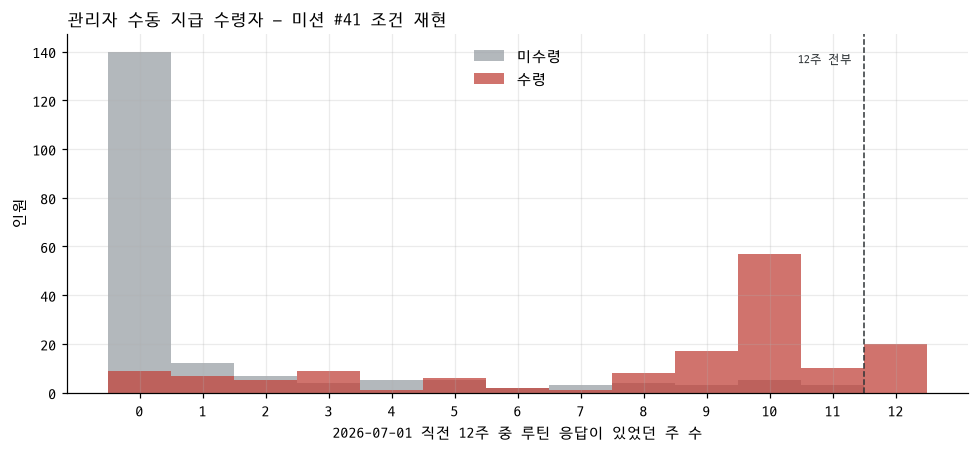

In [9]:
grp = audit.groupby("is_recipient").agg(
    users=("user_no", "size"),
    avg_weeks=("weeks_answered_12w", "mean"),
    n_zero_weeks=("weeks_answered_12w", lambda s: int((s == 0).sum())),
    n_meets_rule=("meets_12w_rule", "sum"))
grp.index = grp.index.map({True: "수령자", False: "미수령 LOOP 사용자"})
show(grp, {"avg_weeks": "{:.1f}"}, index=True)

fig, ax = plt.subplots(figsize=(9, 4.2))
bins = np.arange(0, 14) - 0.5
for flag, name, col in [(False, "미수령", C["muted"]), (True, "수령", C["outstanding"])]:
    ax.hist(audit.loc[audit.is_recipient == flag, "weeks_answered_12w"],
            bins=bins, alpha=0.75, label=name, color=col)
ax.set_xticks(range(13))
ax.set_xlabel("2026-07-01 직전 12주 중 루틴 응답이 있었던 주 수")
ax.set_ylabel("인원")
ax.set_title("관리자 수동 지급 수령자 — 미션 #41 조건 재현",
             loc="left", fontsize=11)
ax.axvline(11.5, color=C["dark"], ls="--", lw=1)
ax.text(11.4, ax.get_ylim()[1] * 0.92, "12주 전부 ", ha="right", fontsize=8, color=C["dark"])
ax.legend(frameon=False)
plt.show()

배치 인원(240명 / 182명), 정액 5,000P, 그리고 해당 미션들이 한 번도 발화하지 않았다는 사실을 합치면
**자동 지급됐어야 할 미션 보상을 수기로 대납한 것**으로 보입니다.
다만 `tb_point_user_dtl` 에는 지급 사유를 적는 컬럼이 없어 원장만으로는 확정할 수 없습니다 — 운영팀 확인이 필요합니다.

#### "12주"를 어떻게 정의하느냐에 따라 충족자 수가 크게 달라집니다

`#41` 의 조건을 액면대로 "12주 내내 매주 응답"으로 읽으면 충족자가 절반에 못 미칩니다.
그러나 이 수치는 **12주 창을 어디에 놓느냐, 분모를 무엇으로 잡느냐에 매우 민감합니다.**
아래 네 가지 해석을 모두 계산해 비교합니다 (대상: `#41` 이 적용될 batch1 수령자 240명).

In [10]:
b1 = audit[audit.batch.isin(["batch1_only", "both"])]

interp = pd.DataFrame([
    {"해석": "(A) 고정 달력창 04-08~06-30, 12주 내내 응답",
     "충족": int(b1.meets_12w_rule.sum())},
    {"해석": "(A) 고정 달력창, 루틴이 배정된 주는 전부 응답",
     "충족": int(b1.answered_every_eligible_week.sum())},
    {"해석": "(B) 사용자별 창(루틴 시작+12주), 12주 내내 응답",
     "충족": int(b1.meets_own12_rule.sum())},
    {"해석": "(B) 사용자별 창, 3주 이하만 응답 (미달 의심)",
     "충족": int((b1.own12_weeks_answered <= 3).sum())},
])
interp["batch1 대비"] = (interp.충족 / len(b1)).map("{:.0%}".format)
show(interp)

print(f"batch1 수령자 {len(b1)}명 기준\n")
print(f"루틴 배정이 12주 미만인 사람        : {int((b1.weeks_assigned_12w < 12).sum())}명 "
      f"— 배정이 없는 주에는 응답할 방법이 없습니다")
print(f"지급일까지 루틴 이력이 12주 미만    : {int(b1.under_12w_at_payout.sum())}명 "
      f"(최소 {b1.weeks_on_routine_at_payout.min():.1f}주)")
print(f"  → 이들에게는 '12주 완주' 규칙 자체가 적용될 수 없습니다.")

해석,충족 인원,batch1 대비
"(A) 고정 달력창 04-08~06-30, 12주 내내 응답",110,46%
"(A) 고정 달력창, 루틴이 배정된 주는 전부 응답",141,59%
"(B) 사용자별 창(루틴 시작+12주), 12주 내내 응답",137,57%
"(B) 사용자별 창, 3주 이하만 응답 (미달 의심)",22,9%


batch1 수령자 240명 기준

루틴 배정이 12주 미만인 사람        : 89명 — 배정이 없는 주에는 응답할 방법이 없습니다
지급일까지 루틴 이력이 12주 미만    : 82명 (최소 8.3주)
  → 이들에게는 '12주 완주' 규칙 자체가 적용될 수 없습니다.


#### 그래서 어떻게 읽어야 하나

- **지급 대상이 무작위가 아닌 것은 분명합니다.** 수령자와 미수령자의 응답 이력 차이는 어떤 정의로 재도
  뒤집히지 않습니다 (사용자별 창 기준 평균 10.2주 vs 3.2주).
- **다만 어떤 정의로도 240명을 정확히 재현하지 못합니다.** 특히 지급일까지 루틴 이력이 12주에
  못 미친 사람이 82명(최소 8.3주) 있습니다. 이들은 규칙을 어긴 것이 아니라 **규칙의 대상이 아니었을**
  가능성이 큽니다.
- 따라서 실제 지급 명단은 루틴 응답 이력이 아니라, **이 웨어하우스에 없는 별도 명단**
  (울산 프로그램 등록자 로스터 등)이었을 것으로 보입니다. `tb_ext_user_preinfo.region_cd` 는
  전원 `KR` 이라 지역 구분에 쓸 수 없습니다.
- 앞서 "엄격 해석 충족자 114명뿐"이라고 본 것은 **고정 달력창이라는 이 분석의 가정이 만든 수치**이지,
  과다 지급의 증거가 아닙니다.

#### 그럼에도 확인이 필요한 부분

In [11]:
weak     = b1[b1.own12_weeks_answered <= 3]        # 자기 창 기준으로도 응답이 거의 없음
nodone   = recip[recip.routine_done_30d == 0]      # 최근 30일 루틴 수행 0건
noassign = recip[recip.routine_assigned_30d == 0]  # 최근 30일 루틴 배정 자체가 없음

for name, sub in [("자기 창 12주 중 3주 이하 응답 (batch1)", weak),
                  ("최근 30일 루틴 수행 0건", nodone),
                  ("최근 30일 루틴 배정 자체가 없음", noassign)]:
    print(f"{name:<34} {len(sub):>3}명  {sub.points_granted.sum():>9,.0f}P "
          f"({sub.points_granted.sum()/recip.points_granted.sum():.1%})")

print("\n창 정의를 바꿔도 남는 소수이므로, 이 인원만 운영팀에 대조를 요청하면 됩니다.")

자기 창 12주 중 3주 이하 응답 (batch1)        22명    115,000P (5.4%)
최근 30일 루틴 수행 0건                     30명    155,000P (7.3%)
최근 30일 루틴 배정 자체가 없음                  5명     25,000P (1.2%)

창 정의를 바꿔도 남는 소수이므로, 이 인원만 운영팀에 대조를 요청하면 됩니다.


---
## 2. 발행 집중도 — 무분별하게 새는 포인트 찾기

"무분별"의 조작적 정의를 두 가지로 나눕니다.

1. **사용자 편중** — 소수 사용자가 발행액의 큰 몫을 가져가는가 (Gini, 상위 10% 점유율)
2. **재량 지급** — 룰 없이 나가는 포인트의 비중

Gini 는 0(완전 균등) ~ 1(한 사람 독식). 미션 성격상 어느 정도 편차는 정상이므로,
같은 성격의 미션끼리 비교하는 용도로 봅니다.

In [12]:
def gini(x: np.ndarray) -> float:
    """포인트 분배의 지니계수. 값이 없거나 전부 0이면 NaN."""
    x = np.sort(np.asarray(x, dtype=float))
    if x.size == 0 or x.sum() == 0:
        return np.nan
    n = x.size
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))


def top_share(x: np.ndarray, q: float = 0.10) -> float:
    """상위 q 비율 사용자가 가져간 포인트 몫."""
    x = np.sort(np.asarray(x, dtype=float))[::-1]
    if x.size == 0 or x.sum() == 0:
        return np.nan
    k = max(1, int(np.ceil(x.size * q)))
    return float(x[:k].sum() / x.sum())


conc = (earn.groupby("point_mission_no")
        .agg(earners=("user_no", "nunique"),
             points=("points_30d", "sum"),
             gini=("points_30d", lambda s: gini(s.values)),
             top10_share=("points_30d", lambda s: top_share(s.values)),
             max_user_points=("points_30d", "max"))
        .reset_index())
conc["label"] = conc.point_mission_no.map(label)
conc["points_per_earner"] = conc.points / conc.earners
conc["max_user_share"] = conc.max_user_points / conc.points

focus = conc[conc.earners >= 20].sort_values("gini", ascending=False)
show(focus[["label", "earners", "points", "points_per_earner",
            "gini", "top10_share", "max_user_share"]],
     {"points": "{:,.0f}", "points_per_earner": "{:,.0f}",
      "gini": "{:.3f}", "top10_share": "{:.1%}", "max_user_share": "{:.1%}"})

미션,적립자,포인트,적립자당 포인트,지니계수,상위10% 몫,최다 1인 몫
댓글 쓰기,28,"2,280",81,0.727,59.4%,25.4%
글쓰기(30자+),32,"1,610",50,0.624,62.1%,23.0%
좋아요 10개,27,597,22,0.569,37.2%,14.1%
일일 피드백,201,"198,900",990,0.523,29.8%,1.5%
출석 1·2·4·5일차,270,"1,590",6,0.503,29.6%,1.2%
식단 등록,155,"127,300",821,0.454,22.2%,1.4%
루틴 1개 응답,246,"207,900",845,0.416,21.2%,0.9%
출석 3·6일차,101,868,9,0.396,22.4%,2.1%
기분 기록 1~6일,214,"33,750",158,0.340,19.6%,0.9%
생활문진 업데이트,208,"42,200",203,0.281,20.1%,1.2%


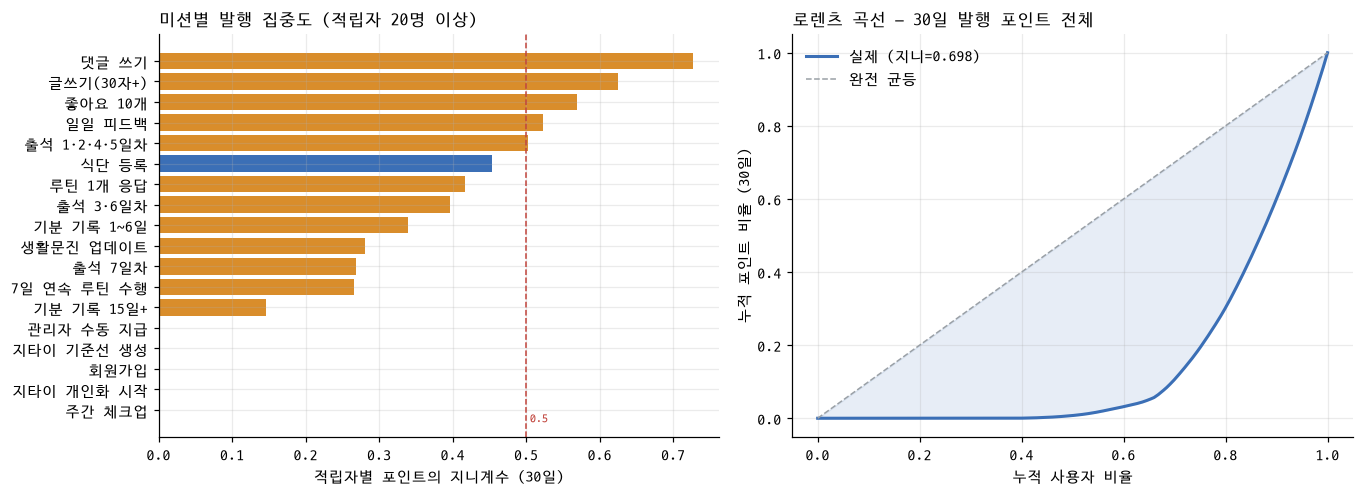

30일 발행 포인트의 40.5% 를 상위 10% 사용자가 가져갑니다.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

# (a) 미션별 집중도
ax = axes[0]
f = focus.sort_values("gini")
cols = [C["accent"] if n in TAUTOLOGICAL else C["issued"] for n in f.point_mission_no]
ax.barh(f.label, f.gini, color=cols)
ax.set_xlabel("적립자별 포인트의 지니계수 (30일)")
ax.set_title("미션별 발행 집중도 (적립자 20명 이상)", loc="left", fontsize=11)
ax.axvline(0.5, color=C["outstanding"], ls="--", lw=1)
ax.text(0.505, -0.6, "0.5", color=C["outstanding"], fontsize=8)

# (b) 사용자 단위 로렌츠 곡선
ax = axes[1]
pts = np.sort(users.points_earned_30d.values)
cum = np.concatenate([[0], np.cumsum(pts) / pts.sum()])
frac = np.linspace(0, 1, cum.size)
ax.plot(frac, cum, color=C["issued"], lw=2, label=f"실제 (지니={gini(pts):.3f})")
ax.plot([0, 1], [0, 1], color=C["muted"], ls="--", lw=1, label="완전 균등")
ax.fill_between(frac, cum, frac, color=C["issued"], alpha=0.12)
ax.set_xlabel("누적 사용자 비율")
ax.set_ylabel("누적 포인트 비율 (30일)")
ax.set_title("로렌츠 곡선 — 30일 발행 포인트 전체", loc="left", fontsize=11)
ax.legend(frameon=False, loc="upper left")
plt.show()

top10 = top_share(users.points_earned_30d.values)
print(f"30일 발행 포인트의 {top10:.1%} 를 상위 10% 사용자가 가져갑니다.")

막대 색: 주황 = 미션이 세는 행동과 우리가 쓰는 활동 지표가 같은 미션(동어반복 후보), 파랑 = 그 외.

---
## 3. 사용자 활동의 상관 구조

미션별 분석에 들어가기 전에, 활동 지표들이 서로 얼마나 겹치는지부터 봅니다.
활동 지표가 서로 강하게 상관돼 있다면 "이 미션 참여자가 활동적이다"는 관찰은
거의 모든 미션에서 자동으로 성립하게 되고, 그만큼 미션별 차이를 읽기 어려워집니다.

분포가 크게 치우쳐 있어 **Spearman 순위상관**을 씁니다.

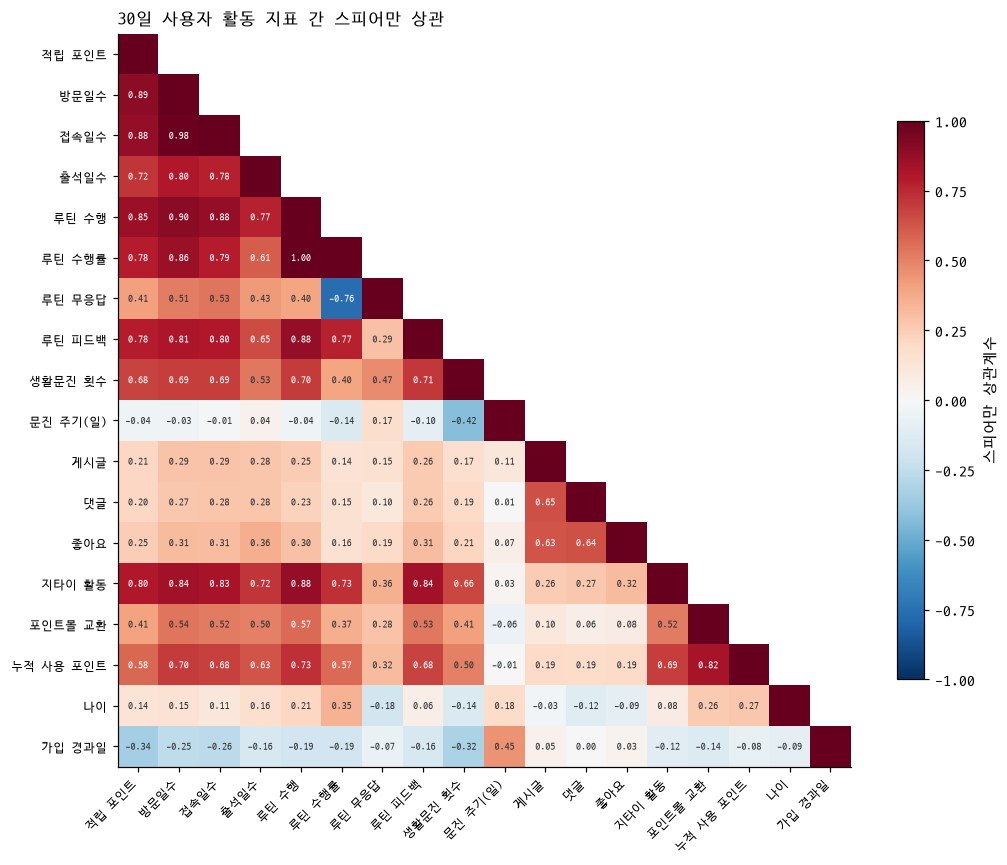

In [14]:
METRICS = {
    "points_earned_30d":       "적립 포인트",
    "visit_days_30d":          "방문일수",
    "login_days_30d":          "접속일수",
    "attendance_days_30d":     "출석일수",
    "routine_done_30d":        "루틴 수행",
    "routine_done_rate_30d":   "루틴 수행률",
    "routine_no_response_30d": "루틴 무응답",
    "routine_fdbk_cnt_30d":    "루틴 피드백",
    "survey_cnt_30d":          "생활문진 횟수",
    "survey_median_gap_days":  "문진 주기(일)",
    "post_publish_cnt_30d":    "게시글",
    "comment_cnt_30d":         "댓글",
    "post_like_cnt_30d":       "좋아요",
    "jitai_action_cnt_30d":    "지타이 활동",
    "coupon_issue_cnt_30d":    "포인트몰 교환",
    "points_spent_total":      "누적 사용 포인트",
    "age":                     "나이",
    "tenure_days":             "가입 경과일",
}

corr = users[list(METRICS)].corr(method="spearman")
corr.index = corr.columns = list(METRICS.values())

fig, ax = plt.subplots(figsize=(9.6, 8.2))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(np.where(mask, np.nan, corr), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(i + 1):
        v = corr.iloc[i, j]
        if i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(v) > 0.55 else C["dark"])
ax.set_title("30일 사용자 활동 지표 간 스피어만 상관", loc="left", fontsize=11)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="스피어만 상관계수")
plt.show()

`루틴 수행` 과 `루틴 수행률` 은 ρ = 0.997 로 사실상 같은 변수입니다(배정 루틴 수가 사용자별로
크게 다르지 않아서입니다). 4절에서 성과 지표로는 비율 쪽 하나만 씁니다.

In [15]:
pe = corr.loc["적립 포인트"].drop("적립 포인트").sort_values(ascending=False)
print("포인트 적립량과 가장 강하게 함께 움직이는 지표 (Spearman):")
for name, v in pe.head(6).items():
    print(f"  {v:+.3f}  {name}")
print("\n가장 약하거나 반대 방향:")
for name, v in pe.tail(3).items():
    print(f"  {v:+.3f}  {name}")

포인트 적립량과 가장 강하게 함께 움직이는 지표 (Spearman):
  +0.893  방문일수
  +0.875  접속일수
  +0.853  루틴 수행
  +0.800  지타이 활동
  +0.783  루틴 수행률
  +0.782  루틴 피드백

가장 약하거나 반대 방향:
  +0.140  나이
  -0.041  문진 주기(일)
  -0.343  가입 경과일


---
## 4. 미션별 참여 효과 — 전체 활동량을 통제한 뒤

각 미션에 대해 "이 미션을 적립한 사람"과 "적립하지 않은 사람"의 **루틴 수행률**을 비교합니다.
루틴 수행률을 핵심 성과 지표로 잡은 이유는, 이 앱이 실제로 팔고 있는 가치가
커뮤니티 활동이 아니라 **건강 루틴의 지속**이기 때문입니다.

그냥 비교하면 "활발한 사람은 뭐든 다 한다"는 교란이 그대로 들어옵니다. 그래서
`visit_days_30d`(전체 접속량)을 통제 변수로 넣은 OLS 회귀의 참여 더미 계수를 함께 봅니다.

- `raw_diff` — 단순 평균 차이 (교란 포함)
- `adj_coef` — 접속일수를 통제한 뒤의 차이 ← **이쪽을 본다**
- `p_adj` — 그 계수의 p-value
- `tautology` — 미션이 세는 행동이 곧 성과 지표인 경우 (해석 무의미)

In [16]:
import statsmodels.api as sm

# 루틴이 배정된 사용자만 대상 (루틴 수행률이 정의되는 모집단)
pop = users[users.routine_assigned_30d > 0].copy()
OUTCOME, CONTROL = "routine_done_rate_30d", "visit_days_30d"
pop = pop.dropna(subset=[OUTCOME, CONTROL])
print(f"분석 모집단: {len(pop)}명 (30일 내 루틴이 배정된 사용자)")

earners_by_mission = earn.groupby("point_mission_no").user_no.apply(set)

rows = []
for no, uset in earners_by_mission.items():
    d = pop.assign(joined=pop.user_no.isin(uset).astype(int))
    n1, n0 = int(d.joined.sum()), int((1 - d.joined).sum())
    if n1 < 20 or n0 < 20:          # 양쪽 집단이 너무 작으면 추정이 불안정
        continue
    a, b = d.loc[d.joined == 1, OUTCOME], d.loc[d.joined == 0, OUTCOME]
    model = sm.OLS(d[OUTCOME], sm.add_constant(d[["joined", CONTROL]])).fit()
    rows.append({
        "point_mission_no": no, "label": label(no),
        "n_joined": n1, "n_not": n0,
        "mean_joined": a.mean(), "mean_not": b.mean(),
        "raw_diff": a.mean() - b.mean(),
        "p_raw": stats.mannwhitneyu(a, b, alternative="two-sided").pvalue,
        "adj_coef": model.params["joined"],
        "p_adj": model.pvalues["joined"],
        "tautology": no in TAUTOLOGICAL,
    })

eff = pd.DataFrame(rows).sort_values("adj_coef", ascending=False)
show(eff, {"mean_joined": "{:.3f}", "mean_not": "{:.3f}", "raw_diff": "{:+.3f}",
          "p_raw": "{:.2g}", "adj_coef": "{:+.3f}", "p_adj": "{:.2g}"})

분석 모집단: 303명 (30일 내 루틴이 배정된 사용자)


미션번호,미션,적립자,미적립자,적립자 평균,미적립자 평균,단순 차이,p(단순),조정 계수,p(조정),동어반복
36,7일 연속 루틴 수행,122,181,0.749,0.242,+0.507,6.4e-36,+0.231,2.4e-16,True
39,일일 피드백,201,102,0.606,0.132,+0.474,6.2e-32,+0.180,2e-10,True
109,주간 체크업,150,153,0.662,0.235,+0.428,2.3e-27,+0.164,2.1e-10,False
16,출석 7일차,56,247,0.762,0.375,+0.387,1.8e-14,+0.139,3.5e-06,True
101,관리자 수동 지급,147,156,0.658,0.247,+0.411,3.6e-25,+0.131,6.7e-07,False
15,출석 3·6일차,99,204,0.680,0.333,+0.347,9.9e-17,+0.109,2.2e-05,True
37,루틴 1개 응답,246,57,0.539,0.048,+0.491,9.3e-27,+0.091,0.0097,True
38,식단 등록,155,148,0.614,0.270,+0.344,9e-19,+0.084,0.00095,False
104,기분 기록 1~6일,214,89,0.572,0.144,+0.428,1.3e-24,+0.070,0.024,True
103,지타이 기준선 생성,49,254,0.700,0.397,+0.303,2.1e-08,+0.059,0.063,False


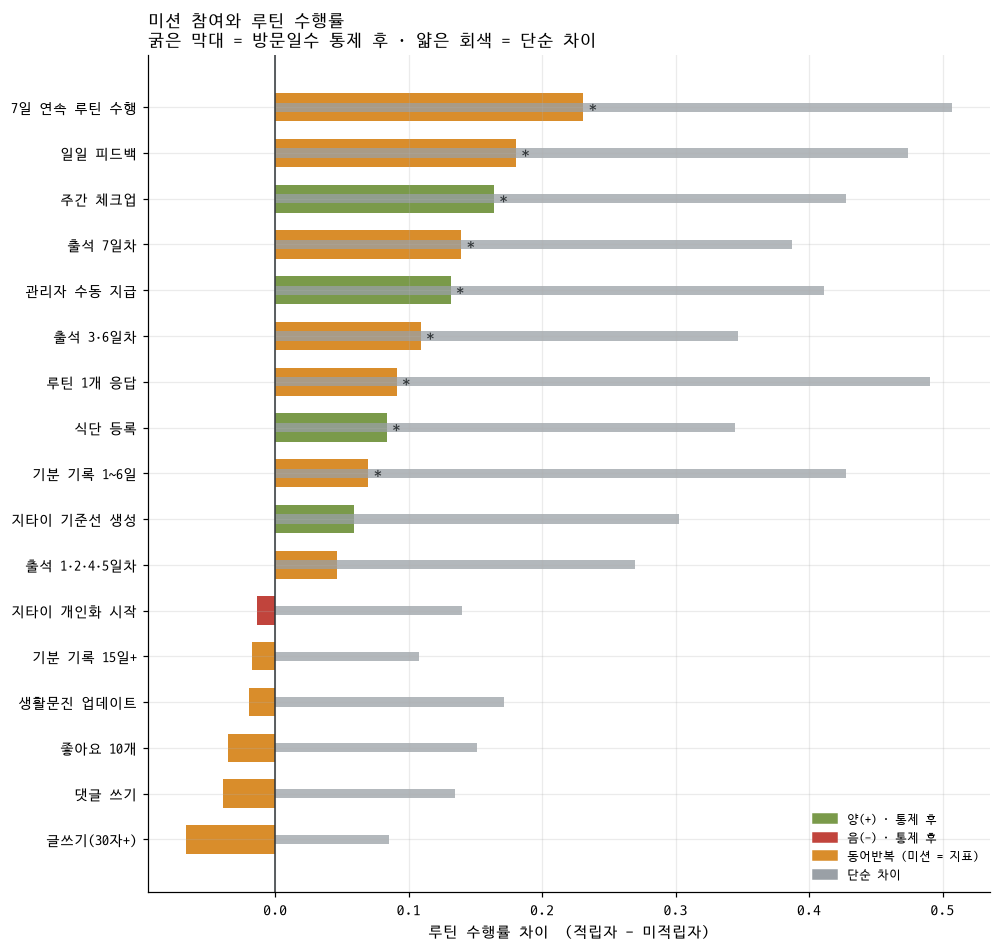

*  조정 계수의 p < 0.05


In [17]:
fig, ax = plt.subplots(figsize=(9.2, 0.42 * len(eff) + 1.6))
e = eff.sort_values("adj_coef")
y = np.arange(len(e))
cols = [C["accent"] if t else (C["used"] if c > 0 else C["outstanding"])
        for t, c in zip(e.tautology, e.adj_coef)]
ax.barh(y, e.adj_coef, color=cols, height=0.62)
ax.barh(y, e.raw_diff, color=C["muted"], height=0.2, alpha=0.75)
ax.set_yticks(y, e.label, fontsize=9)
ax.axvline(0, color=C["dark"], lw=1)
ax.set_xlabel("루틴 수행률 차이  (적립자 − 미적립자)")
ax.set_title("미션 참여와 루틴 수행률\n"
             "굵은 막대 = 방문일수 통제 후 · 얇은 회색 = 단순 차이",
             loc="left", fontsize=11)
for yi, (c, p) in enumerate(zip(e.adj_coef, e.p_adj)):
    if p < 0.05:
        ax.text(c + (0.004 if c >= 0 else -0.004), yi, "*",
                va="center", ha="left" if c >= 0 else "right", fontsize=11, color=C["dark"])
handles = [mpl.patches.Patch(color=C["used"], label="양(+) · 통제 후"),
           mpl.patches.Patch(color=C["outstanding"], label="음(−) · 통제 후"),
           mpl.patches.Patch(color=C["accent"], label="동어반복 (미션 = 지표)"),
           mpl.patches.Patch(color=C["muted"], label="단순 차이")]
ax.legend(handles=handles, frameon=False, loc="lower right", fontsize=8)
plt.show()
print("*  조정 계수의 p < 0.05")

**읽는 법.** 회색(raw) 막대가 굵은 막대(adjusted)보다 크게 나오는 미션이 많다는 것은,
단순 비교가 "활발한 사람 효과"를 미션의 공으로 돌리고 있었다는 뜻입니다.
통제 후에도 계수가 살아 있는 미션이 실제로 루틴 지속과 연결된 미션입니다.

---
## 5. 대체 가능성 — 이 미션을 없애면 실제로 잃는 사용자는 몇 명인가

미션을 없앨 수 있는지 판단하는 가장 직접적인 질문입니다.
어떤 미션의 적립자가 전부 다른 미션에서도 적립하고 있다면, 그 미션을 없애도
**포인트 지출만 줄고 도달하는 사용자 수는 그대로**다.

- `exclusive_earners` — 30일간 **이 미션에서만** 적립한 사용자 수
- `points_30d` — 그 미션이 30일간 발행한 포인트 (= 없앴을 때 절약되는 부채)

> `exclusive_earners = 0` 은 "없애도 된다"는 뜻이 **아니다**. 없애도 포인트를 받는 사용자 수는
> 줄지 않는다는 뜻일 뿐, 그 미션이 유도하던 행동의 유인은 함께 사라집니다.
> 폐지 판단이 아니라 **지급액을 낮출 여지**를 찾는 지표로 씁니다.

In [18]:
missions_per_user = earn.groupby("user_no").point_mission_no.nunique()
solo_users = set(missions_per_user[missions_per_user == 1].index)

overlap = (earn.groupby("point_mission_no")
           .agg(earners=("user_no", "nunique"),
                exclusive_earners=("user_no", lambda s: len(set(s) & solo_users)))
           .reset_index())
overlap["label"] = overlap.point_mission_no.map(label)
overlap = overlap.merge(
    liability[["point_mission_no", "points_issued_30d", "mission_use_yn"]],
    on="point_mission_no", how="left")
overlap["exclusive_rate"] = overlap.exclusive_earners / overlap.earners
overlap["points_per_exclusive"] = np.where(
    overlap.exclusive_earners > 0,
    overlap.points_issued_30d / overlap.exclusive_earners, np.nan)

show(overlap.sort_values("points_issued_30d", ascending=False)
     [["label", "earners", "exclusive_earners", "exclusive_rate",
       "points_issued_30d", "points_per_exclusive"]],
     {"exclusive_rate": "{:.1%}", "points_issued_30d": "{:,.0f}",
      "points_per_exclusive": "{:,.0f}"})

print(f"30일 적립자 {earn.user_no.nunique()}명 중 단 한 개 미션에서만 적립한 사용자: {len(solo_users)}명")

미션,적립자,전속 적립자,전속 비율,30일 발행,전속 1인당 포인트
관리자 수동 지급,148,1,0.7%,"915,000","915,000"
루틴 1개 응답,246,2,0.8%,"267,915","133,958"
일일 피드백,201,0,0.0%,"261,500",nan
7일 연속 루틴 수행,122,0,0.0%,"207,500",nan
식단 등록,155,0,0.0%,"158,780",nan
지타이 기준선 생성,49,0,0.0%,"135,000",nan
생활문진 업데이트,208,7,3.4%,"52,300","7,471"
기분 기록 1~6일,214,1,0.5%,"35,450","35,450"
회원가입,25,11,44.0%,"25,000","2,273"
주간 체크업,150,0,0.0%,"16,000",nan


30일 적립자 325명 중 단 한 개 미션에서만 적립한 사용자: 46명


### 5.1 30일간 한 번도 적립되지 않은 미션

In [19]:
active_30d = set(earn.point_mission_no.unique())
dead = catalog[(~catalog.point_mission_no.isin(active_30d))].copy()
dead["상태"] = np.where(dead.use_yn == "Y", "사용중(use_yn=Y)", "중단(use_yn=N)")
show(dead[["point_mission_no", "label", "description", "상태", "amount",
           "total_unique_users", "last_earn_at"]]
     .sort_values(["상태", "total_unique_users"], ascending=[True, False]))

live_dead = dead[dead.use_yn == "Y"]
print(f"use_yn='Y' 인데 30일간 적립 0건인 미션: {len(live_dead)}개 / 전체 {len(catalog)}개")

미션번호,미션,설명,상태,지급액,누적 적립자,마지막 적립
2,성향문진,성향문진을 통한 사용자 유형 카드 1장 보유,사용중(use_yn=Y),100,309,2025-12-29 07:36:53.095563+09
105,기분 기록 7일,기분 기록 7일,사용중(use_yn=Y),500,31,2026-08-05 10:05:16.024963+09
24,친구 초대 21~50명,"친구 초대 (21~50, 5명당)",사용중(use_yn=Y),100,2,2025-08-26 16:31:33.797194+09
41,12주 완주,12주 동안 주 1회 이상 미션을 응답한 사용자,사용중(use_yn=Y),5000,0,nan
42,만족도 조사,만족도 조사 완료한 사용자,사용중(use_yn=Y),5000,0,nan
106,기분 기록 8~13일,기분 기록 8~13일,사용중(use_yn=Y),100,0,nan
107,기분 기록 14일,기분 기록 14일,사용중(use_yn=Y),1000,0,nan
22,친구 초대 10·20명,"친구 초대 (10, 20명)",사용중(use_yn=Y),1200,0,nan
23,친구 초대 15명,친구 초대 (15명),사용중(use_yn=Y),200,0,nan
25,친구 초대 51~100명,"친구 초대 (51~100, 10명당)",사용중(use_yn=Y),100,0,nan


use_yn='Y' 인데 30일간 적립 0건인 미션: 10개 / 전체 43개


---
## 6. 비용 × 효과 매트릭스

가로축은 30일 발행 포인트(= 부채 증가분), 세로축은 4절의 조정 계수(= 루틴 지속과의 연관).
버블 크기는 도달 사용자 수입니다.

- **오른쪽 아래** — 돈은 많이 나가는데 성과와 연결되지 않음 → 축소·폐지 검토
- **오른쪽 위** — 돈은 나가지만 성과와 연결됨 → 유지
- **왼쪽** — 지출 자체가 작아 우선순위가 낮음

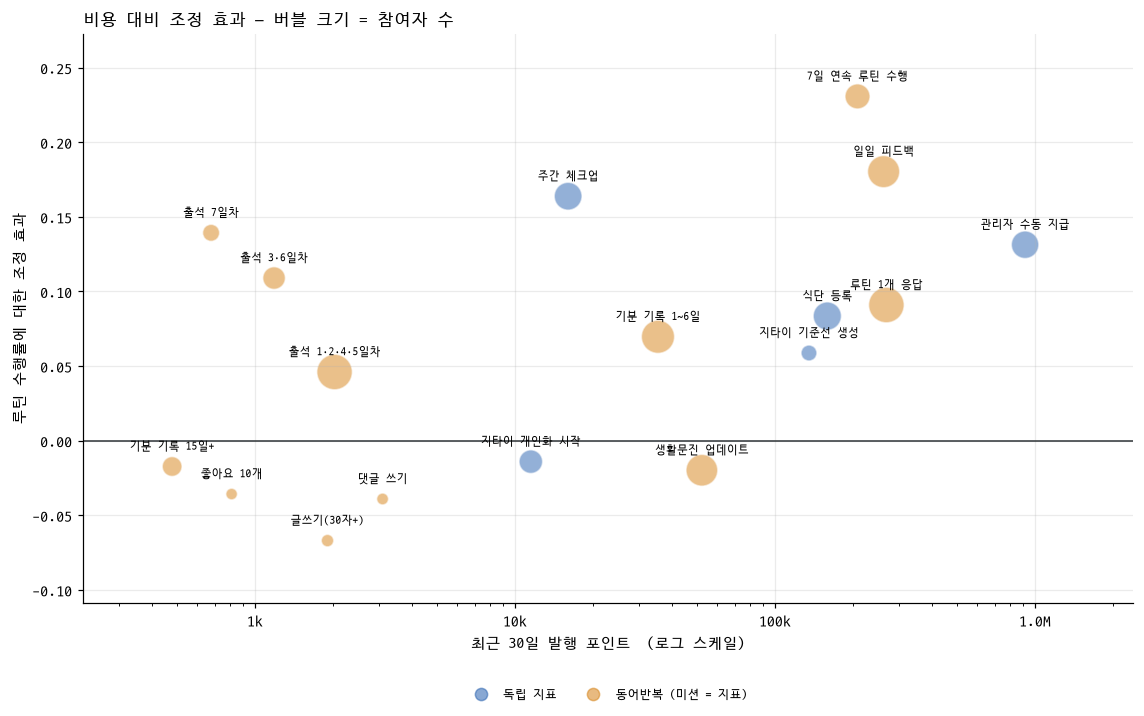

In [20]:
mat = (eff.merge(liability[["point_mission_no", "points_issued_30d"]], on="point_mission_no", how="left")
       .merge(overlap[["point_mission_no", "exclusive_earners", "exclusive_rate"]],
              on="point_mission_no", how="left"))
mat = mat[mat.points_issued_30d > 0]

fig, ax = plt.subplots(figsize=(10.5, 6.6))
for taut, grp in mat.groupby("tautology"):
    ax.scatter(grp.points_issued_30d, grp.adj_coef,
               s=grp.n_joined * 2.2, alpha=0.55,
               color=C["accent"] if taut else C["issued"],
               edgecolor="white", linewidth=1)
for _, r in mat.iterrows():
    ax.annotate(r.label, (r.points_issued_30d, r.adj_coef),
                textcoords="offset points", xytext=(0, 11), ha="center", fontsize=7.5)
ax.set_xscale("log")
ax.axhline(0, color=C["dark"], lw=1)
ax.set_xlabel("최근 30일 발행 포인트  (로그 스케일)")
ax.set_ylabel("루틴 수행률에 대한 조정 효과")
ax.set_title("비용 대비 조정 효과 — 버블 크기 = 참여자 수", loc="left", fontsize=11)

# 라벨이 잘리지 않도록 양쪽에 여유를 준다
lo, hi = mat.points_issued_30d.min(), mat.points_issued_30d.max()
ax.set_xlim(lo / 2.2, hi * 2.6)
ax.margins(y=0.14)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(
    lambda v, _: f"{v/1e6:.1f}M" if v >= 1e6 else (f"{v/1e3:.0f}k" if v >= 1000 else f"{v:.0f}")))

# 범례 마커는 버블 크기와 무관하게 고정 (데이터 위에 얹히지 않도록 축 밖에 배치)
handles = [plt.Line2D([], [], marker="o", ls="", ms=8, color=C["issued"], alpha=0.6,
                      label="독립 지표"),
           plt.Line2D([], [], marker="o", ls="", ms=8, color=C["accent"], alpha=0.6,
                      label="동어반복 (미션 = 지표)")]
ax.legend(handles=handles, frameon=False, fontsize=8, ncol=2,
          loc="upper center", bbox_to_anchor=(0.5, -0.13))
plt.show()

In [21]:
# 30일 발행액 기준 비용 효율: 조정 계수 1%p 당 포인트
mat["cost_per_effect"] = np.where(
    mat.adj_coef > 0, mat.points_issued_30d / (mat.adj_coef * 100), np.nan)

# 관리자 수동 지급은 미션이 아니라 재량 지급입니다. 1.3 에서 확인했듯 12주간 꾸준히 응답한
# 사용자에게 사후 지급한 보상이므로 인과가 반대로 흐른다(활동 → 포인트). 계수가 양수여도
# "효과 있는 미션"으로 읽으면 안 됩니다.
DISCRETIONARY = {101}

verdict = []
for _, r in mat.iterrows():
    if r.point_mission_no in DISCRETIONARY:
        v = "통제 대상 — 재량 지급(인과 역전 의심)"
    elif r.tautology:
        v = "판단보류 — 동어반복"
    elif r.adj_coef > 0 and r.p_adj < 0.05:
        v = "유지"
    elif r.points_issued_30d >= 50_000:
        v = "축소 검토 — 고비용·효과 불명"
    else:
        v = "관망 — 저비용"
    verdict.append(v)
mat["판단"] = verdict

show(mat.sort_values("points_issued_30d", ascending=False)
     [["label", "points_issued_30d", "n_joined", "exclusive_earners",
       "adj_coef", "p_adj", "cost_per_effect", "판단"]],
     {"points_issued_30d": "{:,.0f}", "adj_coef": "{:+.3f}",
      "p_adj": "{:.2g}", "cost_per_effect": "{:,.0f}"})

미션,30일 발행,적립자,전속 적립자,조정 계수,p(조정),효과 1%p당 비용,판단
관리자 수동 지급,"915,000",147,1,+0.131,6.7e-07,"69,682",통제 대상 — 재량 지급(인과 역전 의심)
루틴 1개 응답,"267,915",246,2,+0.091,0.0097,"29,469",판단보류 — 동어반복
일일 피드백,"261,500",201,0,+0.180,2e-10,"14,503",판단보류 — 동어반복
7일 연속 루틴 수행,"207,500",122,0,+0.231,2.4e-16,"8,994",판단보류 — 동어반복
식단 등록,"158,780",155,0,+0.084,0.00095,"19,014",유지
지타이 기준선 생성,"135,000",49,0,+0.059,0.063,"22,984",축소 검토 — 고비용·효과 불명
생활문진 업데이트,"52,300",196,7,-0.020,0.42,nan,판단보류 — 동어반복
기분 기록 1~6일,"35,450",214,1,+0.070,0.024,"5,091",판단보류 — 동어반복
주간 체크업,"16,000",150,0,+0.164,2.1e-10,977,유지
지타이 개인화 시작,"11,500",108,0,-0.014,0.56,nan,관망 — 저비용


---
## 7. 정리

아래 문장은 위 셀의 계산 결과를 그대로 옮긴 것입니다. 숫자가 바뀌면 함께 바뀝니다.

In [22]:
lines = []
lines.append(f"[부채] 누적 발행 {issued:,.0f}P 중 {outstanding:,.0f}P({outstanding/issued:.0%})가 미상환 잔액으로 남아 있습니다.")
lines.append(f"[속도] 최근 30일 발행 {issued_30d:,.0f}P — 하루 {burn:,.0f}P, 연 환산 {burn*365:,.0f}P.")
lines.append(f"[집중] 발행 포인트의 80%를 상위 {n80}개 미션이 만듭니다. 30일 발행의 {top10:.0%}를 상위 10% 사용자가 가져갑니다.")
lines.append(f"[재량] 관리자 수동 지급이 30일 발행의 {admin.points_issued_30d/issued_30d:.0%}, 누적의 {admin.points_issued/issued:.0%}. "
             f"{peak:%Y-%m} 한 달에만 {a_peak:,.0f}P가 나갔고, 이를 빼면 그 달 발행은 전월의 {r_peak/prev:.1f}배에 그칩니다. "
             f"룰이 아니라 사람이 만드는 부채이므로 통제 대상 1순위입니다.")
lines.append(f"[수령자] 그 {recip.points_granted.sum():,.0f}P는 LOOP 사용자 {len(recip)}명에게 5,000P 정액 배치 2건으로 나갔습니다. "
             f"12주 응답 이력이 뚜렷한 집단(평균 {recip.weeks_answered_12w.mean():.1f}주 vs 미수령자 "
             f"{audit.loc[~audit.is_recipient,'weeks_answered_12w'].mean():.1f}주)이므로, "
             f"적립 이력이 0건인 미션 #41/#42(둘 다 5,000P)의 수기 대납으로 보입니다.")
lines.append(f"[기준 불명] 다만 어떤 12주 정의로도 batch1 240명을 재현하지 못합니다. 지급일까지 루틴 이력이 "
             f"12주에 못 미친 사람이 {int(b1.under_12w_at_payout.sum())}명(최소 "
             f"{b1.weeks_on_routine_at_payout.min():.1f}주)이라, 실제 명단은 응답 이력이 아니라 "
             f"웨어하우스에 없는 별도 로스터였을 가능성이 큽니다. 과다 지급으로 단정할 근거는 없습니다.")
lines.append(f"[확인 필요] 창 정의를 바꿔도 남는 소수: 자기 창 12주 중 3주 이하 응답 {len(weak)}명"
             f"({weak.points_granted.sum():,.0f}P), 최근 30일 루틴 수행 0건 {len(nodone)}명"
             f"({nodone.points_granted.sum():,.0f}P). 이 인원만 운영팀 대조를 요청하면 됩니다.")
lines.append(f"[역인과 확인] 관리자 수동 지급의 조정 계수가 양수로 나온 것은 미션 효과가 아니라 "
             f"'꾸준히 응답한 사람에게 사후 지급'한 구조 때문입니다. 4·6절에서 '유지' 판정에서 제외했습니다.")

live_dead_pts = catalog[catalog.point_mission_no.isin(live_dead.point_mission_no)].total_points.sum()
lines.append(f"[사문화] use_yn='Y'인데 30일간 적립 0건인 미션이 {len(live_dead)}개 (누적 발행 {live_dead_pts:,.0f}P).")

keep = mat[mat.판단 == "유지"]
cut  = mat[mat.판단 == "축소 검토 — 고비용·효과 불명"]
if len(keep):
    lines.append("[유지] 접속량 통제 후에도 루틴 수행률과 유의하게 연결된 미션: "
                 + ", ".join(f"{r.label}({r.adj_coef:+.3f})" for _, r in keep.iterrows()))
if len(cut):
    lines.append("[축소 검토] 30일 5만P 이상 발행하면서 조정 효과가 확인되지 않는 미션: "
                 + ", ".join(f"{r.label}({r.points_issued_30d:,.0f}P)" for _, r in cut.iterrows()))

solo_free = (overlap[(overlap.exclusive_earners == 0) & (overlap.points_issued_30d > 0)]
             .sort_values("points_issued_30d", ascending=False))
if len(solo_free):
    lines.append(f"[도달 중복] 전속 적립자가 0명인 미션 {len(solo_free)}개, 30일 발행 합계 "
                 f"{solo_free.points_issued_30d.sum():,.0f}P. 이 미션들을 없애도 '포인트를 받는 사용자'는 "
                 f"한 명도 줄지 않습니다 — 다만 해당 행동을 유도하는 유인은 함께 사라지므로 "
                 f"폐지 근거가 아니라 '금액 조정 여지'로 읽어야 합니다. 상위 5개: "
                 + ", ".join(f"{r.label}({r.points_issued_30d:,.0f}P)"
                             for _, r in solo_free.head(5).iterrows()))

for ln in lines:
    print(ln + "\n")

[부채] 누적 발행 8,224,195P 중 4,214,078P(51%)가 미상환 잔액으로 남아 있습니다.

[속도] 최근 30일 발행 2,120,382P — 하루 70,679P, 연 환산 25,797,981P.

[집중] 발행 포인트의 80%를 상위 6개 미션이 만듭니다. 30일 발행의 41%를 상위 10% 사용자가 가져갑니다.

[재량] 관리자 수동 지급이 30일 발행의 43%, 누적의 26%. 2026-07 한 달에만 2,115,000P가 나갔고, 이를 빼면 그 달 발행은 전월의 1.0배에 그칩니다. 룰이 아니라 사람이 만드는 부채이므로 통제 대상 1순위입니다.

[수령자] 그 2,115,000P는 LOOP 사용자 246명에게 5,000P 정액 배치 2건으로 나갔습니다. 12주 응답 이력이 뚜렷한 집단(평균 10.0주 vs 미수령자 1.5주)이므로, 적립 이력이 0건인 미션 #41/#42(둘 다 5,000P)의 수기 대납으로 보입니다.

[기준 불명] 다만 어떤 12주 정의로도 batch1 240명을 재현하지 못합니다. 지급일까지 루틴 이력이 12주에 못 미친 사람이 82명(최소 8.3주)이라, 실제 명단은 응답 이력이 아니라 웨어하우스에 없는 별도 로스터였을 가능성이 큽니다. 과다 지급으로 단정할 근거는 없습니다.

[확인 필요] 창 정의를 바꿔도 남는 소수: 자기 창 12주 중 3주 이하 응답 22명(115,000P), 최근 30일 루틴 수행 0건 30명(155,000P). 이 인원만 운영팀 대조를 요청하면 됩니다.

[역인과 확인] 관리자 수동 지급의 조정 계수가 양수로 나온 것은 미션 효과가 아니라 '꾸준히 응답한 사람에게 사후 지급'한 구조 때문입니다. 4·6절에서 '유지' 판정에서 제외했습니다.

[사문화] use_yn='Y'인데 30일간 적립 0건인 미션이 10개 (누적 발행 46,700P).

[유지] 접속량 통제 후에도 루틴 수행률과 유의하게 연결된 미션: 주간 체크업(+0.164), 식단 등록(+0.084)

[축소 검토] 30일 5만P 

### 한계

1. **단면 데이터입니다.** 조정 계수는 연관이지 인과가 아닙니다. 미션을 실제로 끄고 전후를 비교하는 것이 유일한 확인 방법입니다.
2. **통제 변수는 `visit_days_30d` 하나입니다.** 재직 기간·나이·JITAI 참여 여부 등을 더 넣으면 계수는 달라질 수 있습니다.
3. **동어반복 미션은 판단하지 않았습니다.** 출석·루틴응답·글쓰기 미션은 성과 지표와 같은 행동을 세므로, 이 프레임으로는 가치를 평가할 수 없습니다. 별도의 지표(리텐션, 이탈률)가 필요합니다.
4. **상환율(`redemption_rate`)은 미션별로 해석하지 않았습니다.** 포인트 사용은 FIFO 로 오래된 lot 부터 소진되므로, 미션별 상환율은 그 미션의 발행 시점이 오래됐다는 뜻일 뿐입니다.
5. **30일은 짧습니다.** 주기가 긴 미션(친구 초대, 12주 완주)은 이 창에서 과소평가됩니다.